In [14]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from autofeat import AutoFeatRegressor
import featuretools as ft

In [15]:
df = pd.read_csv('bostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [16]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [17]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9

In [18]:
df.fillna( df.mode().iloc[0],inplace=True)

X = df.drop(columns=["medv"])
y = df["medv"]

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse_base = mean_squared_error(y_test, y_pred)
r2_base = r2_score(y_test, y_pred)
print("(sans AutoFE)")
print(f"MSE: {mse_base:.2f}, R²: {r2_base:.2f}")

(sans AutoFE)
MSE: 24.77, R²: 0.66


In [21]:
af = AutoFeatRegressor(feateng_steps=2, n_jobs=-1)
X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

model_af = LinearRegression()
model_af.fit(X_train_af, y_train)
y_pred_af = model_af.predict(X_test_af)

mse_af = mean_squared_error(y_test, y_pred_af)
r2_af = r2_score(y_test, y_pred_af)
print("\n Avec AutoFeat")
print(f"MSE: {mse_af:.2f}, R²: {r2_af:.2f}")

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


Nombre de nouvelles features créées : 42

 Avec AutoFeat
MSE: 11.34, R²: 0.85


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


🔹 Baseline (sans AutoFE)
MSE: 24.77, R²: 0.66


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:



🔹 Avec AutoFeat
MSE: 14.99, R²: 0.80


c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


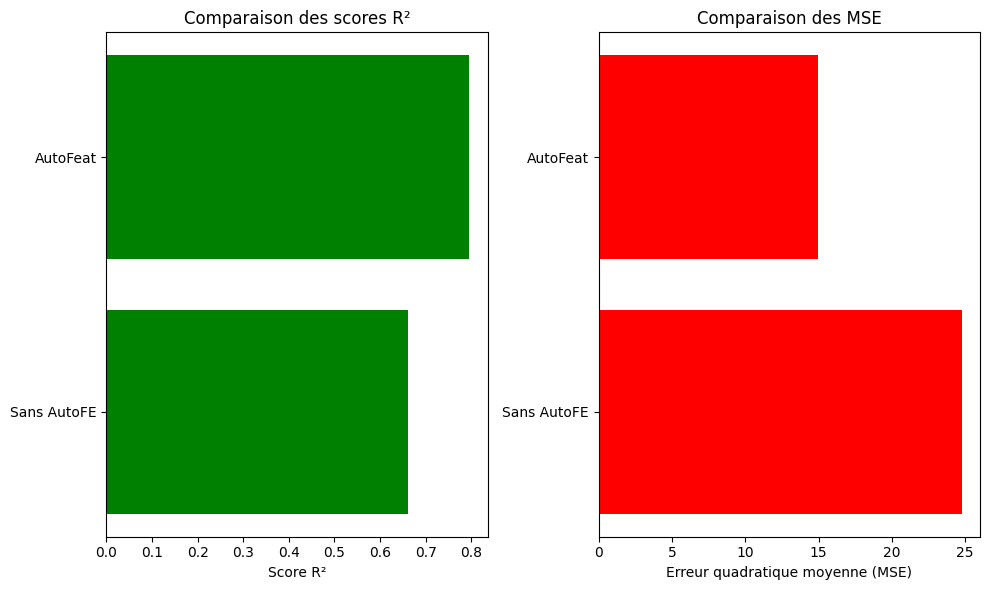

In [ ]:

labels = ["Sans AutoFE", "AutoFeat"]
r2_scores = [r2_base, r2_af]
mse_scores = [mse_base, mse_af]

# Tracé des barres R²
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.barh(labels, r2_scores, color="green")
plt.xlabel("Score R²")
plt.title("Comparaison des scores R²")

# Tracé des barres MSE
plt.subplot(1, 2, 2)
plt.barh(labels, mse_scores, color="red")
plt.xlabel("Erreur quadratique moyenne (MSE)")
plt.title("Comparaison des MSE")

plt.tight_layout()
plt.show()
